# Luma using DTL workflow demonstration

In [1]:
import ee 
import luma_ge

#Option 1: Manual authenticate using personal account
#Instructions for manual authentication
luma_ge.print_auth_instructions()
#uncomment the below line and follow earth engine authentication process
luma_ge.authenticate_manually()

#Option 2: Autheticate using service account (json file)
#service_account_path = '../auth/earth-engine-451407-520c1ef64879.json' #(if failed use this)
service_account_path = '../auth/ee-epstm2024.json'
success = luma_ge.initialize_with_service_account(service_account_path)

if success:
    print("Earth Engine initialized with service account successfully!")
else:
    print("Service account initialization failed. Try to authenticate earth engine manually")

#Check authentication status
status = luma_ge.get_auth_status()
print(f"Initialized: {status['initialized']}")
print(f"Authenticated: {status['authenticated']}")
if status['project']:
    print(f"Project: {status['project']}")


    EARTH ENGINE AUTHENTICATION NOTES:
    
    1. Make sure you already have a google cloud project that has enable the Earth Engine API and registered to 
       commercial or non-commercial use. For more information visit: https://developers.google.com/earth-engine/guides/access 
    
    2. you can authenticate programmatically by calling: from luma_ge.ee_config import authenticate_manually
       authenticate_manually()
    
    3. This will open a web browser. Sign in with your Google account that has Earth Engine access.
    
    4. Copy the authorization code from the browser and paste it in the terminal.
    
    
    For more details, visit: https://developers.google.com/earth-engine/guides/python_install
    


Manual authentication failed: Not signed up for Earth Engine or project is not registered. Visit https://developers.google.com/earth-engine/guides/access
Service account initialization failed: Caller does not have required permission to use project ee-epstm2024. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=ee-epstm2024 and then retry. Propagation of the new permission may take a few minutes.


Earth Engine initialized with service account successfully!
Initialized: True
Authenticated: True
Project: projects/ee-epstm2024/assets/Reference_data_sumsel_test


# Module 1: Acquisition of Near-Cloud-Free Satellite Imagery

In [2]:
import geemap
from luma_ge.data_acquisition import Reflectance_Data, final_Image

### Area of Interest Definition

In [3]:
aoi = geemap.shp_to_ee("../data/modular_mapping_approach/oganilir_modular_td/AOI_Oganilir.shp")

### Satellite imageries retrieval

In [4]:
#========== FIRST RETRIVE THE MULTISPECTRAL BAND===========
#Intialize the relfectance class data function
optical_reflectance = Reflectance_Data()
#Initialize the final image class for composite creation
composite = final_Image() #NEW FEATURE ADDED HERE
#define the start and end date for imagery collection
start = '2017-01-01'
end = '2017-12-31'
#get the image collection and corresponding statistics
landsat_data, meta = optical_reflectance.get_optical_data(aoi, start, end, optical_data='L8_SR', 
                                                           cloud_cover=40, compute_detailed_stats=False)
#create mosaic between image collection, and clip based on AOI
mosaic_landsat = composite.get_quality_mosaic(landsat_data, aoi, quality_band= 'NDVI', calculate_coverage=False) #REPLACE OLD CODE WITH THE NEW ONE HERE
#Alternatively you can use temporal aggregation (ee reducer) to create mode cloudless imagery
#Add new functionality to calculate the coverage of the composite
median_landsat, coverage = composite.get_temporal_composite(landsat_data, aoi, reducer='Median', calculate_coverage=True) #REPLACE OLD CODE WITH THE NEW ONE HERE
#visualization parameter
l8_sr_visparam = {'min': 0,'max': 0.4,'gamma': [0.95, 1.1, 1],'bands':['NIR', 'RED', 'GREEN']}

#retive thermal bands from TOA
thermal_bands, thermal_stats = optical_reflectance.get_thermal_bands(aoi, start, end, cloud_cover=40, thermal_data='L8_TOA', compute_detailed_stats=False)
median_thermal = composite.get_temporal_composite(thermal_bands, aoi, reducer='Median') #REPLACE THE OLD CODE WITH THE NEW ONE
thermal_vis = {'min': 286,'max': 300,'gammma': 0.4}
#stacked all landsat bands and convert to float(making sure all data type are compatible)
stacked_landsat = median_landsat.addBands(median_thermal).toFloat()


2026-05-06 12:04:40,509 - Reflectance_Data - INFO - ReflectanceData initialized.
2026-05-06 12:04:40,510 - final_Image - INFO - final_Image creation initialized.
2026-05-06 12:04:40,511 - Reflectance_Data - INFO - Starting data fetch for Landsat 8 Operational Land Imager Surface Reflectance
2026-05-06 12:04:40,512 - Reflectance_Data - INFO - Date range: 2017-01-01 to 2017-12-31
2026-05-06 12:04:40,512 - Reflectance_Data - INFO - Cloud cover threshold: 40%
2026-05-06 12:04:40,514 - Reflectance_Data - INFO - detailed statistics will not be computed
2026-05-06 12:04:40,515 - Reflectance_Stats - INFO - Reflectance Stats initialized.
2026-05-06 12:04:40,517 - Reflectance_Data - INFO - Filtered collection created (use compute_detailed_stats=True for more information)
2026-05-06 12:04:46,367 - final_Image - INFO - Creating quality mosaic from 11 images using NDVI as quality metric
2026-05-06 12:04:46,370 - final_Image - INFO - Quality mosaic created covering AOI with best available pixels
202

# Module 2:  Land-cover classification Scheme
Upload the classification scheme csv

In [5]:
from luma_ge.classification_scheme import LULC_Scheme_Manager
#Initialize the LULC Scheme Manager
manager = LULC_Scheme_Manager()
print("Land Cover Classification Scheme Manager initialized!")
print(f"Current class count: {manager.get_class_count()}")
#Temporary function to display the classiifcation scheme in notebook
#Display current classification scheme
def display_classification_scheme(manager):
    """Display the current classification scheme in a readable format"""
    if not manager.has_classes():
        print("No classes defined yet.")
        return
    
    print("\n=== Current Classification Scheme ===")
    df = manager.get_dataframe()
    print(df.to_string(index=False))
    
    return df

# Display the scheme
df = display_classification_scheme(manager)

Land Cover Classification Scheme Manager initialized!
Current class count: 0
No classes defined yet.


### System Response 2.1a: Upload Classification Scheme

In [6]:
import pandas as pd
#Reset manager for CSV upload example
manager = LULC_Scheme_Manager()
#path to csv 
csv_path = "../data/modular_mapping_approach/oganilir_modular_td/oganilir_classification_scheme.csv"

print("=== CSV Upload Process ===")

# Load the CSV
df = pd.read_csv(csv_path, sep=None, engine="python")
print("Loaded CSV:")
print(df)

# Auto-detect columns
id_col, name_col, color_col = manager.auto_detect_csv_columns(df)
print(f"\nAuto-detected columns:")
print(f"ID column: {id_col}")
print(f"Name column: {name_col}")
print(f"Color column: {color_col}")

=== CSV Upload Process ===
Loaded CSV:
    ﻿classid                 classname
0          2  Secondary Dryland Forest
1          6    Secondary Swamp Forest
2          8        Rubber monoculture
3          9      Oil palm monoculture
4         13            Other Cropland
5         15       Rubber agroforestry
6         16         Mixed/home Garden
7         17               Paddy Field
8         18          Grass or Savanna
9         20                Settlement
10        21              Cleared Land
11        23                 Waterbody

Auto-detected columns:
ID column: ﻿classid
Name column: classname
Color column: None


In [7]:
# Process CSV upload
success, message = manager.process_csv_upload(df, id_col, name_col, color_col)
if success:
    print(f"✅ {message}")
    
    # Finalize the upload
    success, message = manager.finalize_csv_upload()
    if success:
        print(f"✅ {message}")
    else:
        print(f"❌ {message}")
else:
    print(f"❌ {message}")

# Display the loaded scheme
display_classification_scheme(manager)

classification_df = manager.get_dataframe()

✅ Successfully loaded 12 classes from CSV with auto-generated colors
✅ Skema klasifikasi berhasil dibuat dengan 12 kelas

=== Current Classification Scheme ===
 ID         Land Cover Class Color Palette
  2 Secondary Dryland Forest       #FF6B6B
  6   Secondary Swamp Forest       #4ECDC4
  8       Rubber monoculture       #45B7D1
  9     Oil palm monoculture       #96CEB4
 13           Other Cropland       #FFEAA7
 15      Rubber agroforestry       #DDA0DD
 16        Mixed/home Garden       #98D8C8
 17              Paddy Field       #F7DC6F
 18         Grass or Savanna       #BB8FCE
 20               Settlement       #85C1E9
 21             Cleared Land       #F8C471
 23                Waterbody       #82E0AA


# Module 3: Generate Region Of Interest
Use modular training dataset workflow

### 3.1 Load modular training data

Input: Raw modular training dataset with sample geometries and primitive features.

Expected columns:
- `class_id` (int): Reference land cover class from field data
- `class_name` (str): Human-readable class label
- Primitives

In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
# import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# 
df_train_csv = '../data/modular_mapping_approach/oganilir_modular_td/modular_td_oganilir_v6.csv'
df_train = pd.read_csv(df_train_csv)

#### 3.1.1 Split modular training dataset for thematic validation

In [10]:
VAL_SPLIT          = 0.3    # fraction per class reserved for validation (0.0–1.0)
RANDOM_SEED        = 42     # change for a different random draw; fix for reproducibility
CLASS_COL          = "class_name"   # column to stratify on (must exist in df_train)
MIN_VAL_PER_CLASS  = 3      # always pull at least this many val points per class,
                            # even if VAL_SPLIT × class_size would give fewer

# ─────────────────────────────────────────────────────────────────────────────
# (no edits below this line)
# ─────────────────────────────────────────────────────────────────────────────

import math

if CLASS_COL not in df_train.columns:
    raise ValueError(
        f"Column '{CLASS_COL}' not found in df_train. "
        f"Available columns: {list(df_train.columns)}"
    )

if not (0.0 < VAL_SPLIT < 1.0):
    raise ValueError(f"VAL_SPLIT must be between 0 and 1 exclusive, got {VAL_SPLIT}.")

rng = np.random.default_rng(RANDOM_SEED)

train_parts = []
val_parts   = []
summary_rows = []

for class_label, group in df_train.groupby(CLASS_COL, sort=True):
    n_total = len(group)

    # How many validation points for this class?
    n_val = max(MIN_VAL_PER_CLASS, math.ceil(n_total * VAL_SPLIT))
    n_val = min(n_val, n_total)          # can't exceed class size
    n_train = n_total - n_val

    # Random shuffle within the class
    shuffled_idx = rng.permutation(group.index.to_numpy())
    val_idx      = shuffled_idx[:n_val]
    train_idx    = shuffled_idx[n_val:]

    val_parts.append(group.loc[val_idx])
    train_parts.append(group.loc[train_idx])

    summary_rows.append({
        "class"         : class_label,
        "total"         : n_total,
        "train"         : n_train,
        "validation"    : n_val,
        "val_%"         : f"{n_val / n_total * 100:.1f} %",
    })

df_split_train = pd.concat(train_parts).sample(frac=1, random_state=int(RANDOM_SEED)).reset_index(drop=True)
df_split_val   = pd.concat(val_parts).sample(frac=1, random_state=int(RANDOM_SEED)).reset_index(drop=True)

# ── Summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
total_row  = pd.DataFrame([{
    "class"     : "TOTAL",
    "total"     : summary_df["total"].sum(),
    "train"     : summary_df["train"].sum(),
    "validation": summary_df["validation"].sum(),
    "val_%"     : f"{summary_df['validation'].sum() / summary_df['total'].sum() * 100:.1f} %",
}])
summary_display = pd.concat([summary_df, total_row], ignore_index=True)

print("=" * 62)
print("  STRATIFIED VALIDATION SPLIT")
print("=" * 62)
print(f"  Split ratio   : {VAL_SPLIT:.0%} validation  /  {1 - VAL_SPLIT:.0%} training")
print(f"  Random seed   : {RANDOM_SEED}")
print(f"  Min val/class : {MIN_VAL_PER_CLASS}")
print()
display(summary_display.set_index("class").style.apply(
    lambda row: ["font-weight: bold"] * len(row)
    if row.name == "TOTAL" else [""] * len(row), axis=1
))
print()
print(f"  df_split_train : {len(df_split_train):>5,} rows")
print(f"  df_split_val   : {len(df_split_val):>5,} rows")
print("=" * 62)

# ── Save split outputs ────────────────────────────────────────────────────────
from pathlib import Path

_base = Path(df_train_csv).stem

TRAIN_OUT = Path(df_train_csv).with_name(_base + "_split_train.csv")
VAL_OUT   = Path(df_train_csv).with_name(_base + "_split_val.csv")

df_split_train.to_csv(TRAIN_OUT, index=False)
# df_split_val.to_csv(VAL_OUT,     index=False)

print(f"Training set saved   → {TRAIN_OUT}  ({len(df_split_train):,} rows)")
print(f"Validation set saved → {VAL_OUT}  ({len(df_split_val):,} rows)")
print()
print("Validation set class distribution:")
display(
    df_split_val[CLASS_COL]
    .value_counts()
    .rename("val_count")
    .to_frame()
    .assign(pct=lambda x: (x["val_count"] / x["val_count"].sum() * 100).round(1).astype(str) + " %")
)
    

  STRATIFIED VALIDATION SPLIT
  Split ratio   : 30% validation  /  70% training
  Random seed   : 42
  Min val/class : 3



,total,train,validation,val_%
class,,,,
Cleared Land,80,56,24,30.0 %
Grass or Savanna,24,16,8,33.3 %
Mixed/home Garden,24,16,8,33.3 %
Oil palm monoculture,87,60,27,31.0 %
Other Cropland,56,39,17,30.4 %
Paddy Field,37,25,12,32.4 %
Rubber agroforestry,35,24,11,31.4 %
Rubber monoculture,64,44,20,31.2 %
Secondary Dryland Forest,45,31,14,31.1 %



  df_split_train :   484 rows
  df_split_val   :   216 rows
Training set saved   → ..\data\modular_mapping_approach\oganilir_modular_td\modular_td_oganilir_v6_split_train.csv  (484 rows)
Validation set saved → ..\data\modular_mapping_approach\oganilir_modular_td\modular_td_oganilir_v6_split_val.csv  (216 rows)

Validation set class distribution:


,val_count,pct
class_name,,
Settlement,30,13.9 %
Oil palm monoculture,27,12.5 %
Cleared Land,24,11.1 %
Secondary Swamp Forest,23,10.6 %
Waterbody,22,10.2 %
Rubber monoculture,20,9.3 %
Other Cropland,17,7.9 %
Secondary Dryland Forest,14,6.5 %
Paddy Field,12,5.6 %


### 3.2 Define Ruleset

Each row = one target class with conditions on primitives.

Format:
- `class_id` (int): Target class
- `class_name` (str): Human-readable label
- `priority` (int): Rule evaluation order (lower = checked first)
- Primitive columns: operator string (e.g., `">0.40"`, `"==1"`, `">=25"`)

In [ ]:
# ── DEFINE RULESET ─────────────────────────────────────────────────────────
# Each row = one class rule. Columns are primitives with operators.
# Format: ">0.40" means "greater than 0.40"
#         "==1" means "equal to 1"
#         ">=25" means "greater than or equal to 25"
#         'treecover': '<30 | >80',  means treecover < 30 OR treecover > 80   
#         None means "no condition on this primitive"

ruleset = pd.DataFrame([
    {
        'class_id': 23,
        'class_name': 'Waterbody',
        'priority': 1,
        'waterbody_presence': '>40',
        # 'waterbody_artificiality': '==0'
    },
    {
        'class_id': 20,
        'class_name': 'Fish Pond',
        'priority': 2,
        # 'waterbody_artificiality': '==1',
        'waterbody_presence': '>40',
    },
    {
        'class_id': 20,
        'class_name': 'Settlement',
        'priority': 3,
        'waterbody_presence': '<40',
        'builtup_presence': '>0.9'
    },
    {
        'class_id': 21,
        'class_name': 'Cleared Land',
        'priority': 4,
        'waterbody_presence': '<40',
        'bareSoil_presence': '>0.9',
        'mining': '0'
    },
    {
        'class_id': 22,
        'class_name': 'Mining area',
        'priority': 5,
        'waterbody_presence': '<40',
        'bareSoil_presence': '>0.9',
        'mining': '1'
    },
    {
        'class_id': 1,
        'class_name': 'Primary Dryland Forest',
        'priority': 6,
        'waterbody_presence': '<10',
        'tree_cover': '>0.9',
        'agricultural_activity_type': '==0',
    },
    {
        'class_id': 3,
        'class_name': 'Primary Mangrove Forest',
        'priority': 7,
        'waterbody_presence': '>10',
        'tree_cover': '>0.9',
        'mangrove_presence': '==1',
        'agricultural_activity_type': '==0',
    },
    {
        'class_id': 5,
        'class_name': 'Primary Swamp Forest',
        'priority': 8,
        'waterbody_presence': '>10',
        'tree_cover': '>0.9',
        'agricultural_activity_type': '==0',
    },
    {
        'class_id': 2,
        'class_name': 'Secondary Dryland Forest',
        'priority': 9,
        'waterbody_presence': '<10',
        'tree_cover': '>0.2',
        'agricultural_activity_type': '==0',        
    },
    {
        'class_id': 4,
        'class_name': 'Secondary Mangrove Forest',
        'priority': 10,
        'waterbody_presence': '>10',
        'tree_cover': '>0.2',
        'mangrove_presence': '==1',
        'agricultural_activity_type': '==0',          
    },
    {
        'class_id': 6,
        'class_name': 'Secondary Swamp Forest',
        'priority': 11,
        'waterbody_presence': '>10',
        'tree_cover': '>0.2',
        'agricultural_activity_type': '==0',  
    },
    {
        'class_id': 8,
        'class_name': 'Rubber monoculture',
        'priority': 12,
        'waterbody_presence': '<40',
        'tree_cover': '>0.2',
        'rubber_presence': '==1',
        'agricultural_activity_type': '==1',          
    },
    {
        'class_id': 15,
        'class_name': 'Rubber agroforestry',
        'priority': 13,
        'waterbody_presence': '<40',
        'tree_cover': '>0.2',
        'rubber_presence': '==1',
        'other_species_presence': '==1',
        'agricultural_activity_type': '==1',  
    },
    {
        'class_id': 14,
        'class_name': 'Coffee agroforestry',
        'priority': 14,
        'waterbody_presence': '<40',
        'coffee_presence': '==1',
        'agricultural_activity_type': '==1',  
    },
    {
        'class_id': 10,
        'class_name': 'Cacao monoculture',
        'priority': 15,
        'waterbody_presence': '<40',
        'tree_cover': '>0.2',
        'cacao_presence': '==1',
        'agricultural_activity_type': '==1',  
    },
    {
        'class_id': 12,
        'class_name': 'Other monoculture',
        'priority': 16,
        'waterbody_presence': '<40',
        'tree_cover': '>0.2',
        'other_species_presence': '==1',
        'agricultural_activity_type': '==1',  
    },
    {
        'class_id': 9,
        'class_name': 'Oil palm monoculture',
        'priority': 17,
        'waterbody_presence': '<40',
        # 'tree_cover': '>0.2',
        'oilpalm_presence': '==1',
        'agricultural_activity_type': '==1',
        'tree_horizonal_pattern': '1',
    },
    {
        'class_id': 11,
        'class_name': 'Coconut monoculture',
        'priority': 18,
        'waterbody_presence': '<40',
        # 'tree_cover': '>0.2',
        'coconut_presence': '==1',
        'agricultural_activity_type': '==1',
        'tree_horizonal_pattern': '2',
    },
    {
        'class_id': 7,
        'class_name': 'Plantation forest',
        'priority': 19,
        'waterbody_presence': '<40',
        'tree_cover': '>0.2',
        # 'timber_extraction_rotation': '==1', # DOUBLE CHECK
        'agricultural_activity_type': '==0',  
    },
    {
        'class_id': 19,
        'class_name': 'Shrub',
        'priority': 20,
        'waterbody_presence': '<40',
        'tree_cover': '<0.2',
        'shrub_presence': '>0.2',
        'agricultural_activity_type': '==0',  
    },
    {
        'class_id': 18,
        'class_name': 'Grass or Savanna',
        'priority': 21,
        'waterbody_presence': '<40',
        'tree_cover': '<0.2',
        'herb_presence': '>0.2',
        'agricultural_activity_type': '==0',  
    },
    {
        'class_id': 13,
        'class_name': 'Other Cropland',
        'priority': 22,
        'waterbody_presence': '<40',
        'tree_cover': '<0.2',
        'herb_presence': '>0.2',
        'agricultural_activity_type': '==1',  
    },
    {
        'class_id': 17,
        'class_name': 'Paddy field',
        'priority': 23,
        # 'waterbody_presence': '<40',
        'tree_cover': '<0.2',
        'graminoid_presence': '>0.2',
        'agricultural_activity_type': '==1', 
    },
    {
        'class_id': 16,
        'class_name': 'Mixed/home garden',
        'priority': 24,
        'agricultural_activity_type': '==1', 
    }   
])

print('✓ Ruleset defined')
print(f'  Total rules: {len(ruleset)}')
print(f'  Priority order: {list(ruleset["class_name"])}\n')

ruleset = ruleset.sort_values(by='priority', ascending=True)
ruleset

✓ Ruleset defined
  Total rules: 24
  Priority order: ['Waterbody', 'Fish Pond', 'Settlement', 'Cleared Land', 'Mining area', 'Primary Dryland Forest', 'Primary Mangrove Forest', 'Primary Swamp Forest', 'Secondary Dryland Forest', 'Secondary Mangrove Forest', 'Secondary Swamp Forest', 'Rubber monoculture', 'Rubber agroforestry', 'Coffee agroforestry', 'Cacao monoculture', 'Other monoculture', 'Oil palm monoculture', 'Coconut monoculture', 'Plantation forest', 'Shrub', 'Grass or Savanna', 'Other Cropland', 'Paddy field', 'Mixed/home garden']



,class_id,class_name,priority,waterbody_presence,builtup_presence,bareSoil_presence,mining,tree_cover,agricultural_activity_type,mangrove_presence,...,rubber_presence,other_species_presence,coffee_presence,cacao_presence,oilpalm_presence,tree_horizonal_pattern,coconut_presence,shrub_presence,herb_presence,graminoid_presence
0,23,Waterbody,1,>40,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,Fish Pond,2,>40,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20,Settlement,3,<40,>0.9,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21,Cleared Land,4,<40,NaN,>0.9,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22,Mining area,5,<40,NaN,>0.9,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,Primary Dryland Forest,6,<10,NaN,NaN,NaN,>0.9,==0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3,Primary Mangrove Forest,7,>10,NaN,NaN,NaN,>0.9,==0,==1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5,Primary Swamp Forest,8,>10,NaN,NaN,NaN,>0.9,==0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2,Secondary Dryland Forest,9,<10,NaN,NaN,NaN,>0.2,==0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4,Secondary Mangrove Forest,10,>10,NaN,NaN,NaN,>0.2,==0,==1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
pd.DataFrame.to_clipboard(ruleset)

### 3.3 Parse Ruleset and Assign Labels

For each sample, evaluate rules in priority order. First rule that matches then assign that class.
If no rule matches then assign label 0 (unclassified).

In [12]:
# ── HELPER FUNCTIONS ───────────────────────────────────────────────────────

def safe_num(val, default=0):
    """Convert value to float, return default if None or NaN."""
    if val is None:
        return default
    if isinstance(val, (int, float)):
        if np.isnan(val):
            return default
        return float(val)
    try:
        return float(val)
    except:
        return default

def evaluate_condition(row_val, condition_str):
    """
    Evaluate a single condition: row_val op threshold?
    Supports OR logic with pipe separator: ">0.40|<0.10"
    
    Args:
        row_val: The value from the sample
        condition_str: String like ">0.40", ">=25", ">0.40|<0.10"
    
    Returns:
        bool: True if condition is satisfied, False otherwise
    """
    if condition_str is None:
        return True  # No condition → always passes
    
    condition_str = str(condition_str).strip()
    
    # Handle OR logic (pipe-separated conditions)
    if '|' in condition_str:
        sub_conditions = [c.strip() for c in condition_str.split('|')]
        return any(evaluate_condition(row_val, c) for c in sub_conditions)
    
    # Parse operator and threshold
    if condition_str.startswith('=='):
        op, threshold_str = '==', condition_str[2:]
    elif condition_str.startswith('>='):
        op, threshold_str = '>=', condition_str[2:]
    elif condition_str.startswith('<='):
        op, threshold_str = '<=', condition_str[2:]
    elif condition_str.startswith('>'):
        op, threshold_str = '>', condition_str[1:]
    elif condition_str.startswith('<'):
        op, threshold_str = '<', condition_str[1:]
    else:
        return True  # Invalid condition → pass
    
    threshold = safe_num(threshold_str)
    row_val_num = safe_num(row_val)
    
    if op == '>':
        return row_val_num > threshold
    elif op == '>=':
        return row_val_num >= threshold
    elif op == '<':
        return row_val_num < threshold
    elif op == '<=':
        return row_val_num <= threshold
    elif op == '==':
        return row_val_num == threshold
    
    return False

def check_rule_match(row, rule):
    """
    Check if a sample row matches all conditions in a rule.
    
    Args:
        row: pd.Series with sample data
        rule: pd.Series with rule conditions
    
    Returns:
        bool: True if ALL conditions are satisfied
    """
    # Get all primitive columns (skip metadata like class_id, class_name, priority)
    metadata = {'class_id', 'class_name', 'priority'}
    primitive_cols = [col for col in rule.index if col not in metadata and col != 'treecover_max']
    
    for prim in primitive_cols:
        condition = rule[prim]
        
        # Handle special case for range checks (e.g., treecover_max)
        if pd.isna(condition) or condition is None:
            continue  # No condition on this primitive
        
        row_val = row.get(prim, np.nan)
        
        if not evaluate_condition(row_val, condition):
            return False  # Any condition fails → rule doesn't match
    
    return True  # All conditions passed

print('✓ Helper functions defined')

✓ Helper functions defined


In [13]:
# ── ASSIGN LABELS VIA DECISION RULES ───────────────────────────────────────

def assign_label(row, ruleset):
    """
    Evaluate all rules in priority order. First match → assign that class.
    If no match → return 0 (unclassified).
    
    This mirrors GEE's nested ee.Algorithms.If logic:
    Each rule's NO branch continues to the next rule.
    First YES match stops evaluation.
    """
    # Sort by priority to ensure correct evaluation order
    ruleset_sorted = ruleset.sort_values('priority').reset_index(drop=True)
    
    for _, rule in ruleset_sorted.iterrows():
        if check_rule_match(row, rule):
            return rule['class_id']
    
    return 0  # No rule matched → unclassified

# Apply to all training samples
print('[Step 3] Assigning labels via decision rules...')

# # IF only use a subset of a class, then apply this instead:
# ruleset_subset = ruleset[ruleset['class_id'].isin([23, 20, 13])]  # Only 3 classes
# df_train['label'] = df_train.apply(lambda row: assign_label(row, ruleset_subset), axis=1)
ruleset_subset = ruleset[ruleset['class_id'].isin([2, 6, 8, 9, 13, 15, 16, 17, 18, 20, 21, 23])]
df_split_train['label'] = df_split_train.apply(lambda row: assign_label(row, ruleset_subset), axis=1)

print(f'✓ Labels assigned to {len(df_split_train)} samples\n')
print('Label distribution (assigned):')
print(df_split_train['label'].value_counts().sort_index())
print(f'\nUnclassified (label=0): {(df_split_train["label"] == 0).sum()}')

[Step 3] Assigning labels via decision rules...
✓ Labels assigned to 484 samples

Label distribution (assigned):
label
0       7
2     102
6      55
8      27
9      45
13      1
16     83
20     69
21     68
23     27
Name: count, dtype: int64

Unclassified (label=0): 7


### 3.4 (Optional) Evaluate result with pre-labelled class name

[Step 5] Evaluating rule assignment
Training samples after rule assignment: 477 (excluded 7 unclassified)

Overall Accuracy: 0.6059 (60.59%)

Confusion Matrix (rows=actual, cols=predicted):
[[31  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 48  0  0  0  0  1  0  0  0  1  0]
 [44  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  3 45  0  0 11  0  0  0  1  0]
 [ 9  0  0  0  0  0 26  0  0  0  4  0]
 [ 0  0 22  0  0  0  2  0  0  0  0  0]
 [ 0  0  2  0  0  0 14  0  0  0  0  0]
 [ 0  0  0  0  1  0 21  0  0  0  3  0]
 [ 9  0  0  0  0  0  4  0  0  0  3  0]
 [ 0  0  0  0  0  0  0  0  0 69  0  1]
 [ 0  0  0  0  0  0  0  0  0  0 56  0]
 [ 9  7  0  0  0  0  4  0  0  0  0 26]]

Per-class metrics (for assigned samples only):

Class  2 (Secondary Dryland Forest ): TP= 31, FP= 71, FN=  0 | Precision=0.304, Recall=1.000, F1=0.466
Class  6 (Secondary Swamp Forest   ): TP= 48, FP=  7, FN=  2 | Precision=0.873, Recall=0.960, F1=0.914
Class  8 (Rubber monoculture       ): TP=  0, FP= 27, FN= 44 | Precision=0.000, Recall

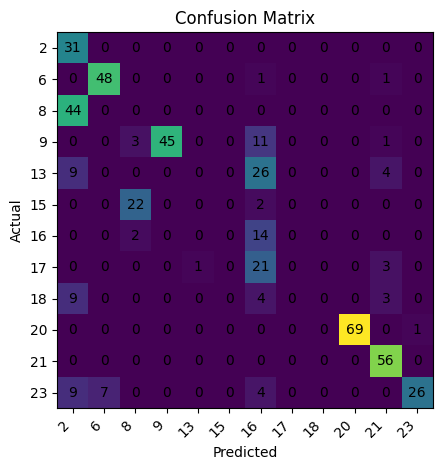

In [14]:
# ── CONFUSION MATRIX & ACCURACY ────────────────────────────────────────────

import sklearn
import numpy as np
import matplotlib.pyplot as plt

print('[Step 5] Evaluating rule assignment')
print('=' * 70)

# Filter out unclassified samples (label != 0)
df_classified = df_split_train[df_split_train['label'] != 0].copy()

print(f'Training samples after rule assignment: {len(df_classified)} '
      f'(excluded {len(df_split_train) - len(df_classified)} unclassified)')

if len(df_classified) == 0:
    print('⚠ No samples classified — ruleset may be too restrictive')

else:
    # ── BUILD VALID CLASS LIST ──────────────────────────────────────────────
    valid_classes = []
    class_metrics = {}

    total_samples = len(df_classified)

    for class_id in sorted(ruleset['class_id'].unique()):
        tp = ((df_classified['class_id'] == class_id) & (df_classified['label'] == class_id)).sum()
        fp = ((df_classified['class_id'] != class_id) & (df_classified['label'] == class_id)).sum()
        fn = ((df_classified['class_id'] == class_id) & (df_classified['label'] != class_id)).sum()
        tn = total_samples - (tp + fp + fn)

        class_metrics[class_id] = {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

        # Keep only classes that actually appear or are predicted
        if not (tp == 0 and fp == 0 and fn == 0):
            valid_classes.append(class_id)

    # Extra safety: ensure class exists in y_true
    valid_classes = [
        c for c in valid_classes
        if (df_classified['class_id'] == c).any()
    ]

    if len(valid_classes) == 0:
        print('⚠ No valid classes found after filtering')
    else:
        # ── CONFUSION MATRIX ────────────────────────────────────────────────
        cm = sklearn.metrics.confusion_matrix(
            df_classified['class_id'],
            df_classified['label'],
            labels=valid_classes
        )

        accuracy = sklearn.metrics.accuracy_score(
            df_classified['class_id'],
            df_classified['label']
        )

        print(f'\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

        print(f'\nConfusion Matrix (rows=actual, cols=predicted):')
        print(cm)

        # ── PER-CLASS METRICS ──────────────────────────────────────────────
        print('\n' + '=' * 70)
        print('Per-class metrics (for assigned samples only):\n')

        for class_id in valid_classes:
            class_name = ruleset.loc[
                ruleset['class_id'] == class_id, 'class_name'
            ].values

            class_name = class_name[0] if len(class_name) > 0 else 'Unknown'

            tp = class_metrics[class_id]['tp']
            fp = class_metrics[class_id]['fp']
            fn = class_metrics[class_id]['fn']

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = (2 * precision * recall / (precision + recall)
                  if (precision + recall) > 0 else 0)

            print(f'Class {class_id:2d} ({class_name:25s}): '
                  f'TP={tp:3d}, FP={fp:3d}, FN={fn:3d} | '
                  f'Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}')

        # ── PLOT CONFUSION MATRIX ──────────────────────────────────────────
        labels = valid_classes

        fig, ax = plt.subplots()
        im = ax.imshow(cm)

        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title('Confusion Matrix')

        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

        # Annotate cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j],
                        ha="center", va="center")

        plt.tight_layout()
        plt.show()

### 3.5 Save labelled training dataset

In [15]:
# save to csv
# Keep only required columns
df_output = df_split_train[['class_id', 'class_name', 'label']].copy()

# Rename label column
df_output = df_output.rename(columns={'label': 'new_class_id'})

# Export to CSV
df_output.to_csv("../temp/oganilir_labelled_dataset.csv", index=False)

In [16]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df_split_train["longitude"], df_split_train["latitude"])]
gdf = gpd.GeoDataFrame(df_split_train, geometry=geometry)
gdf.to_file("../temp/oganilir_labelled_dataset.shp")

2026-05-06 12:05:39,855 - pyogrio._io - INFO - Created 484 records


### Original Luma Module 3 workflow

Load the saved modular TD shapefile

In [17]:
# Modul 3a 
# Import modules and functions
from luma_ge.sample_data import SyncTrainData

In [18]:
LULCTable = classification_df
TrainVectPath = "../temp/oganilir_labelled_dataset.shp"

TrainField = 'label' 
        # Load and process training data
TrainDataDict = SyncTrainData.LoadTrainData(
            landcover_df=LULCTable,
            aoi_geometry=aoi,
            training_shp_path=TrainVectPath
        )

2026-05-06 12:05:40,154 - luma_ge.sample_data - INFO - Loading training data from shapefile: ../temp/oganilir_labelled_dataset.shp
2026-05-06 12:05:40,173 - luma_ge.sample_data - WARNING - 'kelas' field not found in training data
2026-05-06 12:05:40,174 - luma_ge.sample_data - INFO - Available columns: ['class_id', 'latitude', 'longitude', 'class_name', 'LC_type', 'tree_prese', 'tree_cover', 'vegetation', 'shrub_pres', 'herb_prese', 'graminoid_', 'builtup_pr', 'building_p', 'bareSoil_p', 'bare_soil_', 'waterbody_', 'artificial', 'constructi', 'vegetati_1', 'elev', 'slope_deg', 'aspect_deg', 'timber_ext', 'agricultur', 'residentia', 'oilpalm_pr', 'rubber_pre', 'mangrove_p', 'coffee_pre', 'other_spec', 'label', 'geometry']


In [19]:
# ----- System response 3.2.a -----
# Set class field
TrainDataDict = SyncTrainData.SetClassField(TrainDataDict, TrainField)

# Validate classes
TrainDataDict = SyncTrainData.ValidClass(TrainDataDict, 1)

    # Check sample sufficiency
TrainDataDict = SyncTrainData.CheckSufficiency(TrainDataDict, min_samples=20)

    # Filter by AOI
TrainDataDict = SyncTrainData.FilterTrainAoi(TrainDataDict)

    # Create training data table
table_df, total_samples, insufficient_df = SyncTrainData.TrainDataRaw(
    training_data=TrainDataDict.get('training_data'),
    landcover_df=TrainDataDict.get('landcover_df'),
    class_field=TrainDataDict.get('class_field'))

#Summary result
vr = TrainDataDict.get('validation_results', {})

print("=" * 70)
print("TRAINING DATA SUMMARY")
print("=" * 70)
print(f"Total training points loaded     : {vr.get('total_points', 'N/A')}")
print(f"Points after class filtering     : {vr.get('points_after_class_filter', 'N/A')}")
print(f"Valid points (inside AOI)        : {vr.get('valid_points', 'N/A')}")
print(f"Invalid classes found            : {len(vr.get('invalid_classes', []))}")
print(f"Points outside AOI               : {len(vr.get('outside_aoi', []))}")
print("=" * 70)

    # --- Display the main table ---
if table_df is not None and not table_df.empty:
        display_df = table_df.copy()
        if 'Percentage' in display_df.columns:
            display_df['Percentage'] = display_df['Percentage'].apply(
                lambda x: f"{x:.2f}%" if isinstance(x, (int, float)) else x
            )
        display(display_df)
else:
        print("No valid training data available to display.")

TrainDataFinal = TrainDataDict.get('training_data')

2026-05-06 12:05:40,192 - luma_ge.sample_data - INFO - Validating classes with use_class_ids=1
2026-05-06 12:05:40,193 - luma_ge.sample_data - INFO - Class field: label
2026-05-06 12:05:40,194 - luma_ge.sample_data - INFO - Training data type: <class 'geopandas.geodataframe.GeoDataFrame'>
2026-05-06 12:05:40,195 - luma_ge.sample_data - INFO - Landcover DF columns: ['ID', 'Land Cover Class', 'Color Palette']
2026-05-06 12:05:40,196 - luma_ge.sample_data - INFO - Valid IDs in landcover_df: [2, 6, 8, 9, 13, 15, 16, 17, 18, 20, 21, 23]
2026-05-06 12:05:40,196 - luma_ge.sample_data - INFO - Processing GeoDataFrame with 484 features
2026-05-06 12:05:40,197 - luma_ge.sample_data - INFO - Unique classes in training data: [20  2 16  6 23  8 21  0  9 13]
2026-05-06 12:05:40,198 - luma_ge.sample_data - INFO - Valid class ID: 20
2026-05-06 12:05:40,199 - luma_ge.sample_data - INFO - Valid class ID: 2
2026-05-06 12:05:40,199 - luma_ge.sample_data - INFO - Valid class ID: 16
2026-05-06 12:05:40,200 

TRAINING DATA SUMMARY
Total training points loaded     : 484
Points after class filtering     : 477
Valid points (inside AOI)        : 484
Invalid classes found            : 1
Points outside AOI               : 0


,ID,LULC_class,Sample_Count,Percentage
0,2,2,102,21.38%
1,16,16,83,17.40%
2,20,20,69,14.47%
3,21,21,68,14.26%
4,6,6,55,11.53%
5,9,9,45,9.43%
6,23,23,27,5.66%
7,8,8,27,5.66%
8,13,13,1,0.21%


# Module 6: Land Cover Classification

### Library Import

In [20]:
from luma_ge.classification import FeatureExtraction, Generate_LULC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Split training data

In [21]:
labeled_roi = geemap.gdf_to_ee(TrainDataFinal)

#Perform Training Test Split
features = FeatureExtraction()
strafied_train, stratified_test = features.stratified_split(labeled_roi, stacked_landsat, 
                            class_prop='class_id', train_ratio=1)


2026-05-06 12:05:40,295 - pyogrio._io - INFO - Created 477 records


Stratified Random Split Training Pixel Size: 477
Stratified Random Split Testing Pixel Size: 0


### Classification

In [22]:
classifier = Generate_LULC()
print("Performing Classification...")
#Multiclass hard classification
classification_map, trained_model = classifier.hard_classification(strafied_train, class_property='class_id', image=stacked_landsat,
                                                          ntrees=300, min_leaf=2, return_model=True)
# Evaluate model performance
# print("Evaluating model performance...")

# try:
#     accuracy_metrics = classifier.evaluate_model(
#         trained_model=trained_model,
#         test_data=stratified_test,
#         class_property='class_id'
#     )
    
#     print("✓ Model evaluation completed")
    
# except Exception as e:
#     print(f"❌ Error in model evaluation: {e}")                                                    


Performing Classification...


In [23]:
# # Display accuracy results
# print("=== Model Performance Summary ===")
# print(f"Overall Accuracy: {accuracy_metrics['overall_accuracy']:.4f} ({accuracy_metrics['overall_accuracy']*100:.2f}%)")
# print(f"Kappa Coefficient: {accuracy_metrics['kappa']:.4f}")
# print(f"Overall G-Mean: {accuracy_metrics['overall_gmean']:.4f}")

# print("\n=== Per-Class Metrics ===")
# #Class Dataframe
# metrics_df = pd.DataFrame({
#     'Precision': accuracy_metrics['precision'],
#     'Recall': accuracy_metrics['recall'],
#     'F1-Score': accuracy_metrics['f1_scores'],
#     'G-Mean': accuracy_metrics['gmean_per_class']
# })

# # Round to 4 decimal places
# metrics_df = metrics_df.round(4)

# ## QUICK FIX CLEAN UP FOR NON-EXISTING CLASSES
# metrics_df = metrics_df[(metrics_df != 0).any(axis=1)]

# display(metrics_df)

# # Visualize confusion matrix
# confusion_matrix = np.array(accuracy_metrics['confusion_matrix'])
# plt.figure(figsize=(8, 6))
# sns.heatmap(confusion_matrix, 
#             annot=True, 
#             fmt='d', 
#             cmap='Blues')
# plt.title('Confusion Matrix')
# plt.xlabel('Predicted Class')
# plt.ylabel('Actual Class')
# plt.tight_layout()
# plt.show()

2026-05-06 12:06:53,557 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-06 12:06:53,559 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


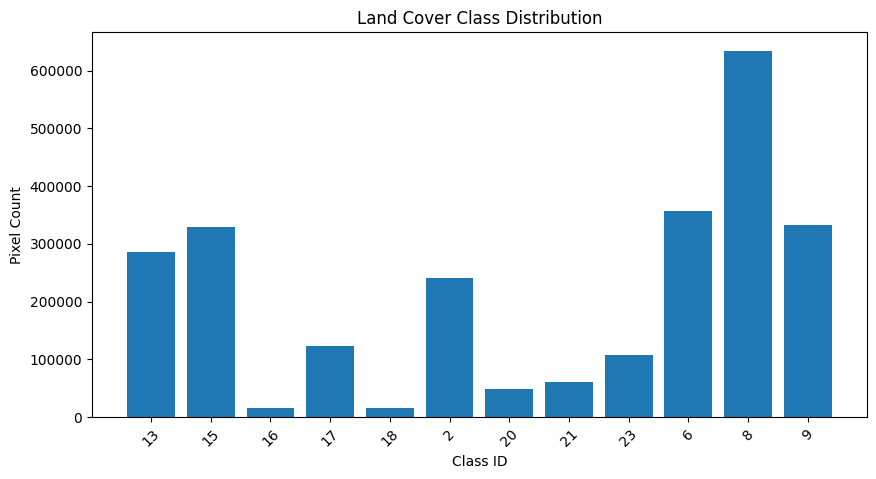

In [24]:
orig_hist = classification_map.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=30,
    maxPixels=1e13
).getInfo()

hist = orig_hist['classification']  

labels = list(hist.keys())
values = list(hist.values())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xlabel("Class ID")
plt.ylabel("Pixel Count")
plt.title("Land Cover Class Distribution")
plt.xticks(rotation=45)

plt.show()

### Visualization

In [25]:
# === Load Classification Scheme ===
scheme = classification_df
classes = [str(x).strip() for x in scheme["Land Cover Class"].tolist()]
palette = [str(x).strip() for x in scheme["Color Palette"].tolist()]
ids = scheme["ID"].tolist()
legend_dict = dict(zip(classes, palette))

# === Visualization Parameters ===
vis_params = {
    "min": min(ids),
    "max": max(ids),
    "palette": palette
}

# === Create geemap Map ===
Map = geemap.Map() 
Map.centerObject(aoi, 7)
Map.addLayer(classification_map, vis_params, "LULC Classification")

# # === Add Legend ===
Map.add_legend(
    title="Land Cover Classification", 
    legend_dict=legend_dict
    )

# Display
Map


Map(center=[-3.4152616959981676, 104.60534276364243], controls=(WidgetControl(options=['position', 'transparen…

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Extract RF Predictions at Validation Points

# Build reverse mapping from ID to class name
CLASS_ID_TO_NAME = dict(zip(ruleset['class_id'], ruleset['class_name']))

# Convert validation points to EE FeatureCollection and sample predictions
print('[Step 7] Extracting RF predictions for validation points...')

# Create GeoDataFrame from validation split with geometry
val_geometry = [Point(xy) for xy in zip(df_split_val["longitude"], df_split_val["latitude"])]
gdf_val = gpd.GeoDataFrame(df_split_val.reset_index(drop=True), geometry=val_geometry, crs='EPSG:4326')

# Add custom index property to track features
gdf_val['feature_idx'] = range(len(gdf_val))

# Convert to EE FeatureCollection
val_fc = geemap.gdf_to_ee(gdf_val)

# Sample the classification map at each validation point
print('  Sampling classification map at validation points...')
sampled = classification_map.sampleRegions(
    collection=val_fc,
    scale=30,
    geometries=True
).getInfo()

print(f'  Sampled {len(sampled["features"])} out of {len(df_split_val)} points')

# Create a mapping from properties to predictions
# Initialize all predictions as 0 (unclassified)
predicted_ids = [0] * len(df_split_val)
sample_indices = []

# Extract predicted class IDs from samples and track which indices were sampled
for feature in sampled['features']:
    if 'properties' in feature:
        props = feature['properties']
        
        # Try to get the feature index
        idx = None
        if 'feature_idx' in props:
            try:
                idx = int(props['feature_idx'])
            except (ValueError, TypeError):
                pass
        
        # If we got an index and classification value, update the prediction
        if idx is not None and 0 <= idx < len(df_split_val):
            if 'classification' in props:
                try:
                    pred_id = int(props['classification'])
                    predicted_ids[idx] = pred_id
                    sample_indices.append(idx)
                except (ValueError, TypeError):
                    pass

print(f'  Successfully extracted predictions for {len(sample_indices)} points')
if len(sample_indices) < len(df_split_val):
    missing = len(df_split_val) - len(sample_indices)
    print(f'  ⚠  {missing} points outside map bounds (marked as unclassified)')

# Add predictions to validation dataframe
df_split_val['rf_predicted_id'] = predicted_ids
df_split_val['rf_predicted_name'] = df_split_val['rf_predicted_id'].map(CLASS_ID_TO_NAME).fillna('Unclassified')

print(f'✓ Predictions extracted for {len(df_split_val)} validation points')
print(f'\nPredicted class distribution:')
print(df_split_val['rf_predicted_name'].value_counts())


2026-05-06 12:07:03,843 - pyogrio._io - INFO - Created 216 records


[Step 7] Extracting RF predictions for validation points...
  Sampling classification map at validation points...
  Sampled 213 out of 216 points
  Successfully extracted predictions for 213 points
  ⚠  3 points outside map bounds (marked as unclassified)
✓ Predictions extracted for 216 validation points

Predicted class distribution:
rf_predicted_name
Oil palm monoculture        32
Settlement                  31
Secondary Swamp Forest      25
Rubber monoculture          24
Waterbody                   23
Other Cropland              21
Cleared Land                20
Rubber agroforestry         15
Secondary Dryland Forest    14
Paddy field                  6
Unclassified                 3
Grass or Savanna             2
Name: count, dtype: int64


# Module 7: Thematic Validation

The "independent" validation points are from the split of the original class-labelled modular training data

In [27]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  MODULE 7: MAP VALIDATION CONFIGURATION                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Build ID-to-Name mapping from ruleset (already defined above)
ID2NAME = dict(zip(ruleset['class_id'], ruleset['class_name']))

# ── VALIDATION SETTINGS (EDIT HERE) ────────────────────────────────────────
# Use df_split_val with RF predictions extracted from classification_map
VERIFIED_VAL_PATH  = df_split_val.copy()                    # Validation data with RF predictions
MAP_VERIFIED_COL   = "class_name"                           # Original field label column
VERIFIED_COL_TYPE  = "name"                                 # "name" (class names) or "id" (class IDs)
AGREEMENT_COL      = "rf_predicted_name"                    # Compare against RF prediction

print(f"✓ Validation data prepared with {len(VERIFIED_VAL_PATH)} points")
print(f"  True class: {MAP_VERIFIED_COL}")
print(f"  RF prediction: {AGREEMENT_COL}\n")

# Normalize verified column to class names for comparison
df_verified = VERIFIED_VAL_PATH.copy()
df_verified["_verified_name"] = df_verified[MAP_VERIFIED_COL].astype(str).str.strip()

# Filter valid rows (non-empty, not "Unknown")
df_v = df_verified[
    (df_verified["_verified_name"].str.lower() != "") & 
    (df_verified["_verified_name"].str.lower() != "unknown")
].copy()

print(f"Valid comparison rows: {len(df_v)} / {len(df_verified)}\n")

if AGREEMENT_COL not in df_v.columns:
    raise ValueError(f"'{AGREEMENT_COL}' not found in data.")

# Calculate agreement between true class and RF prediction
df_v["map_agreement"] = (
    df_v["_verified_name"].str.lower() == df_v[AGREEMENT_COL].astype(str).str.lower()
)

overall_agree = df_v["map_agreement"].mean()
print(f"RF prediction agreement: {overall_agree:.2%}  ({df_v['map_agreement'].sum()} / {len(df_v)})")
_df_verified_ready = df_v.copy()

✓ Validation data prepared with 216 points
  True class: class_name
  RF prediction: rf_predicted_name

Valid comparison rows: 216 / 216

RF prediction agreement: 59.72%  (129 / 216)


MAP VALIDATION ANALYSIS

Overall agreement : 59.72%
Points validated  : 216

Per-class agreement (worst → best):


,agreed,total,agreement_%
rf_predicted_name,,,
Unclassified,0,3,0.0%
Rubber agroforestry,4,15,26.7%
Paddy field,2,6,33.3%
Other Cropland,7,21,33.3%
Rubber monoculture,12,24,50.0%
Grass or Savanna,1,2,50.0%
Secondary Swamp Forest,15,25,60.0%
Secondary Dryland Forest,10,14,71.4%
Oil palm monoculture,23,32,71.9%


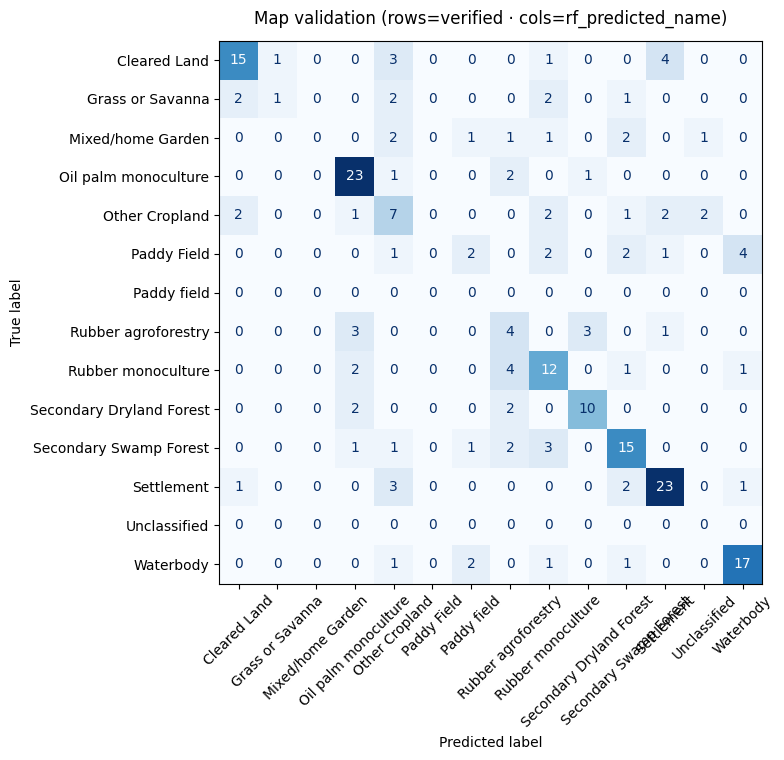


Disagreement pairs (87 points):


,predicted,map_verified,count
0,Settlement,Cleared Land,4
1,Rubber agroforestry,Rubber monoculture,4
2,Waterbody,Paddy Field,4
3,Other Cropland,Settlement,3
4,Other Cropland,Cleared Land,3
5,Rubber monoculture,Secondary Swamp Forest,3
6,Secondary Dryland Forest,Rubber agroforestry,3
7,Oil palm monoculture,Rubber agroforestry,3
8,Cleared Land,Other Cropland,2
9,Cleared Land,Grass or Savanna,2


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# ── STEP C: Visualize & export validation results ───────────────────────────

try:
    df_v = _df_verified_ready
    print("=" * 70)
    print("MAP VALIDATION ANALYSIS")
    print("=" * 70)
except NameError:
    print("⏸  No verified data — run previous cell with VERIFIED_VAL_PATH set.")
    df_v = None

if df_v is not None and len(df_v) > 0:
    
    # Per-class agreement
    per_class_agree = (
        df_v.groupby(AGREEMENT_COL)["map_agreement"]
        .agg(agreed="sum", total="count")
    )
    per_class_agree["agreement_%"] = (
        per_class_agree["agreed"] / per_class_agree["total"] * 100
    ).round(1)
    per_class_agree = per_class_agree.sort_values("agreement_%")

    print(f"\nOverall agreement : {df_v['map_agreement'].mean():.2%}")
    print(f"Points validated  : {len(df_v)}\n")
    print("Per-class agreement (worst → best):")
    display(per_class_agree.style.format({"agreement_%": "{:.1f}%"}))

    # Confusion matrix
    all_labels = sorted(set(df_v["_verified_name"].unique()) | set(df_v[AGREEMENT_COL].astype(str).unique()))
    if len(all_labels) <= 25:
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        import matplotlib.pyplot as plt
        
        cm_map = confusion_matrix(
            df_v["_verified_name"],
            df_v[AGREEMENT_COL].astype(str),
            labels=all_labels
        )
        
        fig, ax = plt.subplots(
            figsize=(max(8, len(all_labels)*0.65), max(6, len(all_labels)*0.55))
        )
        ConfusionMatrixDisplay(cm_map, display_labels=all_labels).plot(
            ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues"
        )
        ax.set_title(
            f"Map validation (rows=verified · cols={AGREEMENT_COL})",
            pad=12
        )
        plt.tight_layout()
        plt.show()

    # Disagreement summary
    disagreed = df_v[~df_v["map_agreement"]][[AGREEMENT_COL, "_verified_name"]].copy()
    disagreed.columns = ["predicted", "map_verified"]
    if not disagreed.empty:
        print(f"\nDisagreement pairs ({len(disagreed)} points):")
        display(
            disagreed.value_counts()
            .rename("count")
            .reset_index()
            .sort_values("count", ascending=False)
        )

    # Export results
    # if 'VAL_PATH' in dir():
    #     out_path = Path(VAL_PATH).with_name# (
    #         Path(VAL_PATH).# stem + "_map_validation_results.csv"
    #     )# 
    #     df_v.to_csv(out_path, index=False)
    #     print(f"\n✅ R# esults save# d → {out_path}")# 